# MCP + LangGraph Multi-Agent Walkthrough

Run this top-to-bottom, one cell at a time. Each section talks to a *different* layer
of the system, in order, so you can see exactly what each piece does before they're
wired together into the full graph:

1. Talk to the MCP server directly (tools + resources), no agents or LLM involved yet
2. Call the RAG retrieval tool directly
3. Walk the LangGraph nodes one at a time, inspecting state after each step
4. Follow the conditional edge manually
5. Run the whole compiled graph in one call, for comparison
6. (Optional) visualize the graph

**Before running:** finish the setup in `README.md` first — venv, `pip install -r
requirements.txt`, and a filled-in `.env` (only `ANTHROPIC_API_KEY` is required;
`ALPHA_VANTAGE_API_KEY` is optional, mock data is used without it). Make sure this
notebook's kernel is the same venv/environment you installed the requirements into,
and that the notebook is running from inside the `mcp-agent-project/` folder (it
needs `mcp_server.py`, `graph.py`, and `knowledge_base/` alongside it).

## 0. RAG Pipeline: Ingestion, Chunking, and Embedding

This section walks through the RAG pipeline that powers the compliance node:
**Ingestion** → **Chunking** → **Embedding** → **Indexing** → **Retrieval**

Run these cells to see each step, then we'll compare semantic embeddings vs. TF-IDF retrieval quality.

### Step 1: Ingestion — Load raw documents

Read all `.txt` files from `knowledge_base/`. Each file represents a compliance policy.

In [2]:
from pathlib import Path

KB_DIR = Path("knowledge_base")
raw_docs = []

for path in sorted(KB_DIR.glob("*.txt")):
    text = path.read_text().strip()
    raw_docs.append({"source": path.name, "text": text})
    print(f"\n{path.name} ({len(text)} chars, {len(text.split())} words):")
    print(text[:150] + "...")

print(f"\nLoaded {len(raw_docs)} documents")


data_quality_policy.txt (326 chars, 48 words):
Data Quality Policy

Any output where the underlying price or fundamental data contains an error
field, is missing, or is malformed must not be auto-a...

earnings_blackout_policy.txt (282 chars, 39 words):
Earnings Blackout Policy

During the two weeks preceding a company's scheduled earnings release,
automated publishing of new analysis is paused and ro...

negative_sentiment_policy.txt (442 chars, 63 words):
Negative Sentiment Review Policy

When recent news sentiment for a security is bearish, negative, or mixed,
any analysis output must receive a seconda...

restricted_list_policy.txt (421 chars, 58 words):
Restricted List Policy

Securities on the internal restricted list may not be auto-published without
manual compliance sign-off. Restricted list membe...

Loaded 4 documents


### Step 2: Chunking — Split documents into overlapping chunks

Large documents are split into smaller, overlapping chunks so retrieval can find the most
relevant *part* of a document, not just the whole thing. Overlap preserves context across
chunk boundaries.

In [3]:
def chunk_text(text: str, chunk_size: int = 256, overlap: int = 50) -> list[str]:
    """Split text into overlapping chunks by word count."""
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = " ".join(words[i : i + chunk_size])
        if chunk.strip():
            chunks.append(chunk)
    return chunks

# Chunk all documents
all_chunks = []
for doc in raw_docs:
    chunks = chunk_text(doc["text"], chunk_size=256, overlap=50)
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "source": doc["source"],
            "chunk_id": i,
            "text": chunk,
        })

print(f"Created {len(all_chunks)} chunks from {len(raw_docs)} documents\n")
print("Example chunks from first document:")
for i, chunk in enumerate(all_chunks[:2]):
    print(f"\nChunk {i} from {chunk['source']}:")
    print(chunk["text"][:200] + "...")

Created 4 chunks from 4 documents

Example chunks from first document:

Chunk 0 from data_quality_policy.txt:
Data Quality Policy Any output where the underlying price or fundamental data contains an error field, is missing, or is malformed must not be auto-approved. Incomplete or unverified data must be flag...

Chunk 1 from earnings_blackout_policy.txt:
Earnings Blackout Policy During the two weeks preceding a company's scheduled earnings release, automated publishing of new analysis is paused and routed to human review. This avoids acting on stale o...


### Step 3: Embedding — Convert chunks to dense vectors

Semantic embeddings (sentence-transformers) convert text into high-dimensional vectors
where semantically similar texts are close together in space. This enables *semantic*
retrieval (meaning-based) vs. keyword-based (TF-IDF).

In [4]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load a small, fast embedding model (384 dims, ~40MB)
# This is all-MiniLM-L6-v2: semantic understanding, good speed/quality tradeoff
print("Loading embedding model (all-MiniLM-L6-v2)...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed all chunks
chunk_texts = [c["text"] for c in all_chunks]
chunk_embeddings = embedding_model.encode(chunk_texts, show_progress_bar=True)

print(f"\nEmbedded {len(all_chunks)} chunks")
print(f"Embedding dimensionality: {chunk_embeddings.shape[1]}")
print(f"Embedding shape: {chunk_embeddings.shape}")
print(f"\nExample embedding (first 10 dims):")
print(chunk_embeddings[0][:10])

Loading embedding model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embedded 4 chunks
Embedding dimensionality: 384
Embedding shape: (4, 384)

Example embedding (first 10 dims):
[-0.01092807  0.02825182 -0.02381812  0.01541047 -0.00501775 -0.05024936
 -0.00547636 -0.06359901 -0.05065847  0.04239703]


### Step 4: Retrieval — Compare semantic embeddings vs. TF-IDF

Query the knowledge base with both methods and see the difference. Semantic embeddings find
*meaning*, while TF-IDF finds *keywords*. Try changing the query below to see how they rank
differently.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Try different queries to see semantic vs. keyword-based retrieval
queries = [
    "bearish sentiment, poor earnings",  # semantic: looks for meaning
    "regulatory restrictions trading",   # semantic: understands compliance
    "stock price drops significantly",   # paraphrasing
]

for query in queries:
    print(f"\n{'='*70}")
    print(f"Query: {query}")
    print(f"{'='*70}")

    # --------- SEMANTIC RETRIEVAL (embeddings) ---------
    query_embedding = embedding_model.encode([query])[0]
    semantic_scores = cosine_similarity([query_embedding], chunk_embeddings)[0]
    semantic_ranking = sorted(
        enumerate(semantic_scores), key=lambda x: x[1], reverse=True
    )[:3]

    print("\n[SEMANTIC] Top 3 chunks:")
    for rank, (idx, score) in enumerate(semantic_ranking, 1):
        chunk = all_chunks[idx]
        print(f"{rank}. {chunk['source']} (score: {score:.3f})")
        print(f"   {chunk['text'][:100]}...")

    # --------- TF-IDF RETRIEVAL (keyword-based) ---------
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(chunk_texts)
    query_tfidf = vectorizer.transform([query])
    tfidf_scores = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    tfidf_ranking = sorted(
        enumerate(tfidf_scores), key=lambda x: x[1], reverse=True
    )[:3]

    print("\n[TF-IDF] Top 3 chunks:")
    for rank, (idx, score) in enumerate(tfidf_ranking, 1):
        chunk = all_chunks[idx]
        print(f"{rank}. {chunk['source']} (score: {score:.3f})")
        print(f"   {chunk['text'][:100]}...")


Query: bearish sentiment, poor earnings

[SEMANTIC] Top 3 chunks:
1. negative_sentiment_policy.txt (score: 0.479)
   Negative Sentiment Review Policy When recent news sentiment for a security is bearish, negative, or ...
2. earnings_blackout_policy.txt (score: 0.414)
   Earnings Blackout Policy During the two weeks preceding a company's scheduled earnings release, auto...
3. data_quality_policy.txt (score: 0.202)
   Data Quality Policy Any output where the underlying price or fundamental data contains an error fiel...

[TF-IDF] Top 3 chunks:
1. negative_sentiment_policy.txt (score: 0.341)
   Negative Sentiment Review Policy When recent news sentiment for a security is bearish, negative, or ...
2. earnings_blackout_policy.txt (score: 0.174)
   Earnings Blackout Policy During the two weeks preceding a company's scheduled earnings release, auto...
3. restricted_list_policy.txt (score: 0.058)
   Restricted List Policy Securities on the internal restricted list may not be auto-published wi

### Summary

The RAG pipeline:
1. **Loaded** 4 policy documents from `knowledge_base/`
2. **Chunked** them into overlapping segments (~256 words with 50-word overlap)
3. **Embedded** chunks with `sentence-transformers` (384-dim semantic vectors)
4. **Indexed** them for fast similarity search
5. **Retrieved** the top-k most relevant chunks for any query

Now when you run the compliance node, it uses this same pipeline to ground the LLM's output
in your actual policy documents, not general knowledge. The next sections show how this
plugs into the MCP server and LangGraph agent.

In [5]:
from dotenv import load_dotenv
load_dotenv()
print("Environment loaded")

Environment loaded


## 1. Talk to the MCP server directly

This spins up `mcp_server.py` as a subprocess (stdio transport) and asks it what
tools it exposes — no LangGraph, no LLM, just the raw MCP handshake.

In [6]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient({
    "stock-tools": {
        "command": "python",
        "args": ["mcp_server.py"],
        "transport": "stdio",
    }
})

tools = await client.get_tools()
for t in tools:
    print(t.name, "-", t.description)

get_stock_price - Fetch the latest closing price for a stock ticker.
retrieve_policy_context - Retrieve the most relevant internal policy excerpts for a query.

Uses semantic embeddings (sentence-transformers) for retrieval, or TF-IDF
as fallback. Returns top-k chunks with similarity scores.



### Call the price tool

In [7]:
price_tool = next(t for t in tools if t.name == "get_stock_price")
price_result = await price_tool.ainvoke({"ticker": "AAPL"})
price_result

[{'type': 'text',
  'text': '{\n  "ticker": "AAPL",\n  "price": 319.70001220703125\n}',
  'id': 'lc_375000e8-bee6-48c0-a435-67d5ed45c587'}]

### Read the two resources

Resources are addressed by URI, not called with arguments like tools — `read_resource`
takes the URI directly.

In [8]:
async with client.session("stock-tools") as session:
    profile = await session.read_resource("stock://AAPL/profile")
    news = await session.read_resource("stock://AAPL/news")

print(profile.contents[0].text)
print()
print(news.contents[0].text)

{
  "ticker": "AAPL",
  "name": "Apple Inc.",
  "sector": "TECHNOLOGY",
  "market_cap": "4665759498000",
  "description": "Apple Inc. is an American multinational technology company that specializes in consumer electronics, computer software, and online services. Apple is the world's largest technology company by revenue (totalling $274.5 billion in 2020) and, since January 2021, the world's most valuable company. As of 2021, Apple is the world's fourth-largest PC vendor by unit sales, and fourth-largest smartphone manufacturer. It is one of the Big Five American information technology companies, along with Amazon, Google, Microsoft, and Facebook."
}

[
  {
    "title": "No recent news found",
    "sentiment": "Neutral"
  }
]


## 2. Call the RAG retrieval tool directly

`retrieve_policy_context` TF-IDF-ranks the `.txt` files in `knowledge_base/` against
whatever query you give it. Try changing the query below and re-running to see the
ranking shift — that's the retrieval half of RAG, isolated from any LLM call.

In [9]:
retrieve_tool = next(t for t in tools if t.name == "retrieve_policy_context")
docs = await retrieve_tool.ainvoke({
    "query": "bearish sentiment, earnings miss, regulatory probe",
    "top_k": 2,
})
docs

[{'type': 'text',
  'text': '{\n  "source": "negative_sentiment_policy.txt",\n  "text": "Negative Sentiment Review Policy When recent news sentiment for a security is bearish, negative, or mixed, any analysis output must receive a secondary human review before downstream automated action is taken. This threshold exists to prevent automated systems from acting on unverified negative developments such as earnings misses, regulatory probes, or executive departures. Bullish or neutral sentiment does not by itself require review.",\n  "score": 0.59\n}',
  'id': 'lc_99f30d82-bc53-43b3-997d-fc7a0c8ca184'},
 {'type': 'text',
  'text': '{\n  "source": "earnings_blackout_policy.txt",\n  "text": "Earnings Blackout Policy During the two weeks preceding a company\'s scheduled earnings release, automated publishing of new analysis is paused and routed to human review. This avoids acting on stale or incomplete information immediately before a material, market-moving disclosure.",\n  "score": 0.531\n}

## 3. Walk the LangGraph nodes one at a time

These are the exact same node functions the compiled graph uses in `graph.py` —
we're just calling them manually, one at a time, on a plain dict, so you can inspect
`state` after every step instead of only seeing the final result.

In [1]:
from graph import (
    research_node, context_node, analyst_node, compliance_node,
    decision_node, route_decision, publish_node, human_review_node,
)

state = {
    "ticker": "AAPL",
    "price_data": {},
    "profile": {},
    "news": [],
    "summary": "",
    "compliance_notes": "",
    "retrieved_docs": [],
    "decision": "",
    "reason": "",
    "status": "",
}
state

{'ticker': 'AAPL',
 'price_data': {},
 'profile': {},
 'news': [],
 'summary': '',
 'compliance_notes': '',
 'retrieved_docs': [],
 'decision': '',
 'reason': '',
 'status': ''}

**research** — calls the `get_stock_price` tool

In [2]:
state = await research_node(state)
state["price_data"]

[{'type': 'text',
  'text': '{\n  "ticker": "AAPL",\n  "price": 319.70001220703125\n}',
  'id': 'lc_364c0f7a-717c-49bb-a847-869ffa0d3d68'}]

**context** — reads the `profile` and `news` resources

In [3]:
state = await context_node(state)
print(state["profile"])
print()
print(state["news"])

{
  "ticker": "AAPL",
  "name": "Apple Inc.",
  "sector": "TECHNOLOGY",
  "market_cap": "4665759498000",
  "description": "Apple Inc. is an American multinational technology company that specializes in consumer electronics, computer software, and online services. Apple is the world's largest technology company by revenue (totalling $274.5 billion in 2020) and, since January 2021, the world's most valuable company. As of 2021, Apple is the world's fourth-largest PC vendor by unit sales, and fourth-largest smartphone manufacturer. It is one of the Big Five American information technology companies, along with Amazon, Google, Microsoft, and Facebook."
}

[
  {
    "title": "No recent news found",
    "sentiment": "Neutral"
  }
]


**analyst** — LLM summarizes price + profile + news

In [4]:
state = await analyst_node(state)
print(state["summary"])

Apple (AAPL) is currently trading at $319.70, with a massive market capitalization of approximately $4.67 trillion, reaffirming its status as one of the world's most valuable companies. As the largest player in the technology sector, Apple continues to benefit from its diversified business spanning consumer electronics, software, and services. There is no significant recent news driving sentiment, suggesting the stock is likely trading on broader market trends and fundamentals rather than company-specific catalysts at this time.


**compliance** — the RAG agent. Retrieves policy chunks with the summary as the
query, then asks the LLM to reason only from those chunks.

In [5]:
state = await compliance_node(state)
print(state["compliance_notes"])
print()
print("Retrieved from:", [d["source"] for d in state["retrieved_docs"]])

Based on the excerpts, neither policy appears clearly triggered: there's no indication of bearish/negative/mixed sentiment (the summary notes no significant news driving sentiment, and neutral sentiment does not require review), and no mention of an upcoming earnings release date that would trigger the blackout period. However, if AAPL has a scheduled earnings release within the next two weeks, the Earnings Blackout Policy would apply and require human review before publishing—this should be verified separately, as the summary does not specify earnings timing.

Retrieved from: ['earnings_blackout_policy.txt', 'negative_sentiment_policy.txt']


**decision** — LLM classifies approve vs. review, informed by the compliance notes

In [6]:
state = await decision_node(state)
print(state["decision"], "-", state["reason"])

review - Compliance notes flag unverified earnings date that could trigger the blackout policy, requiring human confirmation.


## 4. Follow the conditional edge manually

`route_decision` is the plain function LangGraph calls internally to pick the next
node. Calling it yourself makes the branching explicit.

In [7]:
next_step = route_decision(state)
print("Routing to:", next_step)

if next_step == "publish":
    state = await publish_node(state)
else:
    state = await human_review_node(state)

print(state["status"])

Routing to: human_review
FLAGGED FOR HUMAN REVIEW — Compliance notes flag unverified earnings date that could trigger the blackout policy, requiring human confirmation.


## 5. Run the whole compiled graph in one call

Same six steps you just did by hand, now run automatically by LangGraph in a single
`ainvoke`. Try `"BADNEWS"` to see the other branch of the conditional edge fire.

In [8]:
from graph import app

full_result = await app.ainvoke({
    "ticker": "BADNEWS",
    "price_data": {}, "profile": {}, "news": [],
    "summary": "", "compliance_notes": "", "retrieved_docs": [],
    "decision": "", "reason": "", "status": "",
})

print("Decision:", full_result["decision"], "-", full_result["reason"])
print("Status:", full_result["status"])
print("Retrieved from:", [d["source"] for d in full_result["retrieved_docs"]])

Decision: review - No price, profile, or news data exists for BADNEWS, and compliance requires manual verification in this case.
Status: FLAGGED FOR HUMAN REVIEW — No price, profile, or news data exists for BADNEWS, and compliance requires manual verification in this case.
Retrieved from: ['data_quality_policy.txt', 'negative_sentiment_policy.txt']


## 6. (Optional) visualize the graph structure

Requires `graphviz`/mermaid rendering support in your environment. If it fails,
the fallback prints the same structure as text — either way you're looking at the
same graph you just walked through by hand above.

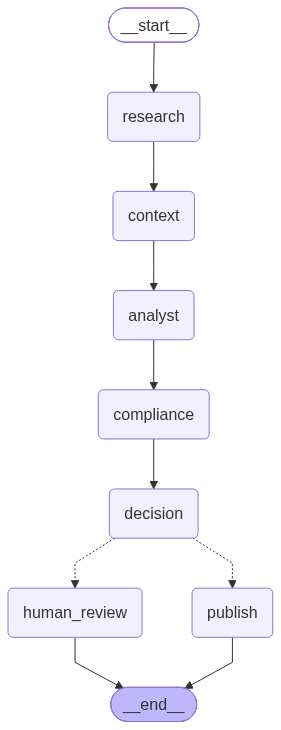

In [9]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Rendering not available in this environment:", e)
    print()
    print(app.get_graph().draw_mermaid())

## Where to go next

This notebook mirrors the "things to try" list in `README.md` — e.g. add a fifth
policy `.txt` file and re-run cell 2 (RAG retrieval) to see it get picked up, or
swap `TfidfVectorizer` for real embeddings and compare retrieval quality on a
paraphrased query. `main.py` remains the quickest way to run the whole thing
end-to-end from the command line once you're done exploring step by step here.